# Benchmarks Hénon Heiles

<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Hénon-Heiles">Initial value problem: Hénon-Heiles</a></li>
    <li><a href="#IRKGL16-integrations">IRKGL16-integrations</a></li>
    <li><a href="#2nd-order-explicit-symplectic-integrations">2nd order explicit symplectic integrations</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precison-diagrams">Work-precison-diagrams</a></li>
        <li><a href="#Error-in-Energy">Error in Energy</a></li>
        <li><a href="#Error-in-Solution">Error in Solution</a></li>
    </ul>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using OrdinaryDiffEq
using LaTeXStrings
using IRKGaussLegendre

PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  ## bertsio lokala exekutatzeko  

include("../Aux_functions.jl")

PATH_ODES=string(PATH_Splitting,"ODEProblems/")
include(string(PATH_ODES,"HenonHeiles.jl"));


In [2]:
Base.@boundscheck false

false

##### <a href="#top">Back to the top</a>

## Initial value problem: Hénon-Heiles

We consider the Hénon-Heiles model which is Hamiltonian with

\begin{align*}
H(q,p)=\frac{1}{2} (p_1^2+p_2^2)+\frac{1}{2}(q_1^2+q_2^2)+q_1^2q_2-\frac{1}{3}q_2^3
\end{align*}

and the corresponding system

\begin{align*}
& \frac{dq_1}{dt}=p_1, \quad 
\frac{dq_2}{dt}=p_2, \\
& \frac{dp_1}{dt}=-q_1-2q_1q_2, \quad 
 \frac{dp_2}{dt}=-q_2-q_1^2+q_2^2
\end{align*}

In [3]:
# Gemetric Numerical Integration. Structure-Preserving Algorithms for Ordinary Differential Equations, page 15

q0=[0,3/10]
p0=[0, 2/10]

# Non-Chaotic solution H0=1/12

H0=1/12
U0=Potential_U(q0[1],q0[2])
p0[1]=sqrt(2*H0-2*U0-p0[2]^2)
parms = [0.]

u0=vcat(q0,p0)
u0_B=BigFloat.(u0)

t0 = 0.
tF = 2*pi*1e4
tspan=(t0,tF);

##### <a href="#top">Back to the top</a>

## IRKGL16 integrations

In [4]:
prob = ODEProblem{true,SciMLBase.FullSpecialize}(HenonHeilesODE!, u0, tspan, parms)

HAM=HenonHeliesHam
@show(HAM(u0, parms));

HAM(u0, parms) = 0.08333333333333333


,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0

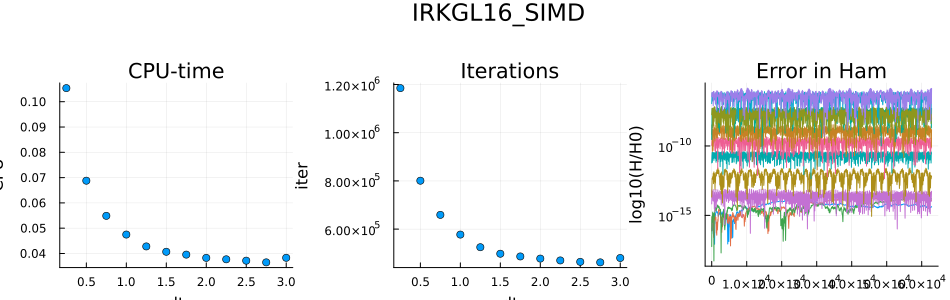

,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0

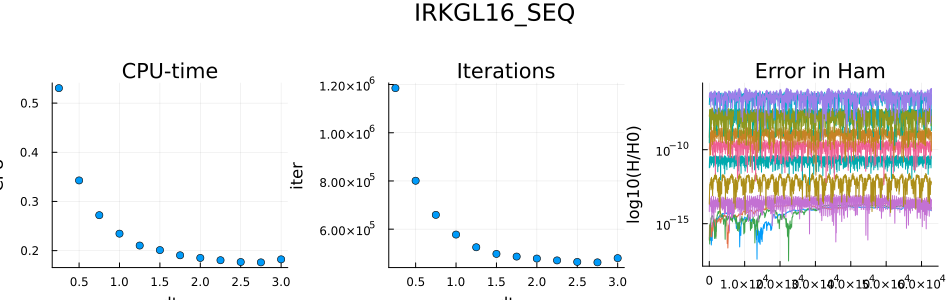

In [5]:
ddt0_irk16=collect(1/4:1/4:3)  
nruns=1

alg=IRKGL16(simd=true, second_order_ode=true)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM, nruns=nruns)
fig=plots_IRKGL16("IRKGL16_SIMD",prob,HAM,sols_irk16_simd)
display(fig)
#
alg=IRKGL16(simd=false, second_order_ode=true)
sols_irk16_gen=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns)
fig=plots_IRKGL16("IRKGL16_SEQ",prob,HAM,sols_irk16_gen)
display(fig)

In [6]:
[sols_irk16_simd.dts sols_irk16_simd.retcodes sols_irk16_simd.iters sols_irk16_simd.cpus sols_irk16_simd.MaxΔHlocal]

12×5 Matrix{Float64}:
 0.25  1.0       1.18494e6  0.105375   3.50545e-16
 0.5   1.0  800861.0        0.0687743  3.85152e-16
 0.75  1.0  659163.0        0.054879   6.09353e-16
 1.0   1.0  577328.0        0.0474778  3.13063e-14
 1.25  1.0  524920.0        0.0427853  1.26398e-12
 1.5   1.0  497931.0        0.0406715  2.52211e-11
 1.75  1.0  486633.0        0.0395451  3.05756e-10
 2.0   1.0  477749.0        0.0382566  2.56567e-9
 2.25  1.0  470116.0        0.0376901  1.6192e-8
 2.5   1.0  464258.0        0.0371556  8.15254e-8
 2.75  1.0  462086.0        0.0364816  3.40396e-7
 3.0   1.0  480211.0        0.0382906  1.2191e-6

In [7]:
[sols_irk16_gen.dts sols_irk16_gen.retcodes sols_irk16_gen.iters sols_irk16_gen.cpus sols_irk16_gen.MaxΔHlocal]

12×5 Matrix{Float64}:
 0.25  1.0       1.18504e6  0.530485  3.50983e-16
 0.5   1.0  800834.0        0.34276   4.64356e-16
 0.75  1.0  659243.0        0.272068  6.30541e-16
 1.0   1.0  577478.0        0.234508  3.14501e-14
 1.25  1.0  524835.0        0.21032   1.26406e-12
 1.5   1.0  497275.0        0.201049  2.52208e-11
 1.75  1.0  486190.0        0.190491  3.05755e-10
 2.0   1.0  477980.0        0.185135  2.56567e-9
 2.25  1.0  470315.0        0.180479  1.6192e-8
 2.5   1.0  464019.0        0.176805  8.15254e-8
 2.75  1.0  462158.0        0.176104  3.40396e-7
 3.0   1.0  479705.0        0.182259  1.2191e-6

<a href="#top">Back to the top</a>

## 2nd order explicit symplectic integrations

In [8]:
flows=[flowH1HenonHeiles!, flowH2HenonHeiles!]
prob=SplittingProblem(flows, u0, tspan, parms)

HAM=HenonHeliesHam
@show(HAM(u0,parms))

HAM(u0, parms) = 0.08333333333333333


0.08333333333333333

### Composition methods

In [9]:
#ddt0_split=vcat(collect(1/20:1/20:0.9)/8, collect(1/80:1/80:1/20)/8)
#ddt0_split=collect(2/80:1/80:1/20)/8 #berriak
#ddt0_split=vcat(collect(2/80:1/80:3/80)/8, collect(1/20:1/20:0.9)/8)
#ddt0_split=vcat(collect(1/2^8:1/2^9:3/2^9), collect(1/2^7:1/2^7:1/2^3))
ddt0_split=vcat(collect(1/2^8:1/2^9:7/2^9), collect(2/2^7:1/2^7:1/2^3))
nruns=1

s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, alg, prob, ddt0_split, HAM, nruns=nruns)
#fig=plots_Splitting("Split r=2", alg, prob, HAM, sols_split_r2)
#display(fig)
#
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns);

,0.00390625,0.005859375,0.0078125,0.009765625,0.01171875,0.013671875,0.015625,0.0234375,0.03125,0.0390625,0.046875,0.0546875,0.0625,0.0703125,0.078125,0.0859375,0.09375,0.1015625,0.109375,0.1171875,0.125,0.01953125,0.029296875,0.0390625,0.048828125,0.05859375,0.068359375,0.078125,0.1171875,0.15625,0.1953125,0.234375,0.2734375,0.3125,0.3515625,0.390625,0.4296875,0.46875,0.5078125,0.546875,0.5859375,0.625,0.05078125,0.076171875,0.1015625,0.126953125,0.15234375,0.177734375,0.203125,0.3046875,0.40625,0.5078125,0.609375,0.7109375,0.8125,0.9140625,1.015625,1.1171875,1.21875,1.3203125,1.421875,1.5234375,1.625,0.08203125,0.123046875,0.1640625,0.205078125,0.24609375,0.287109375,0.328125,0.4921875,0.65625,0.8203125,0.984375,1.1484375,1.3125,1.4765625,1.640625,1.8046875,1.96875,2.1328125,2.296875,2.4609375,2.625,0.13671875,0.205078125,0.2734375,0.341796875,0.41015625,0.478515625,0.546875,0.8203125,1.09375,1.3671875,1.640625,1.9140625,2.1875,2.4609375,2.734375,3.0078125,3.28125,3.5546875,3.828125,

In [10]:
[sols_split_r2.MaxΔHlocal sols_split_r4.MaxΔHlocal sols_split_r6.MaxΔHlocal sols_split_r8.MaxΔHlocal sols_split_r10.MaxΔHlocal] 

21×5 Matrix{Float64}:
 2.51499e-8   6.84741e-11  2.93829e-13  2.30001e-15    2.15361e-15
 8.48808e-8   5.19956e-10  5.01185e-12  3.14455e-14    9.03065e-15
 2.01199e-7   2.19098e-9   3.75328e-11  4.07554e-13    1.72893e-13
 3.92966e-7   6.68592e-9   1.78893e-10  3.02477e-12    1.99184e-12
 6.79046e-7   1.66351e-8   6.40665e-10  1.5571e-11     1.47259e-11
 1.0783e-6    3.59528e-8   1.88363e-9   6.21832e-11    7.98168e-11
 1.60959e-6   7.00886e-8   4.79326e-9   2.06194e-10    3.44521e-10
 5.43236e-6   5.31946e-7   8.15909e-8   7.79866e-9     2.87889e-8
 1.28767e-5   2.2397e-6    6.08045e-7   1.01517e-7     6.49323e-7
 2.51498e-5   6.82901e-6   2.87998e-6   7.3479e-7      7.09762e-6
 4.3459e-5    1.69725e-5   1.02358e-5   3.66081e-6     4.87465e-5
 6.90115e-5   3.66335e-5   2.98273e-5   1.4069e-5      0.000242333
 0.000103015  7.13056e-5   7.51386e-5   4.46431e-5     0.000944105
 0.000146678  0.000128261  0.000169291  0.000121845    0.00305407
 0.000201207  0.000216769  0.000349145  0.000

### RKN symplectic integrations

In [11]:
s=14; r=6
nruns=1

alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn6=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=19; r=8; rkn=true
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn8=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns);

,0.0546875,0.08203125,0.109375,0.13671875,0.1640625,0.19140625,0.21875,0.328125,0.4375,0.546875,0.65625,0.765625,0.875,0.984375,1.09375,1.203125,1.3125,1.421875,1.53125,1.640625,1.75,0.07421875,0.111328125,0.1484375,0.185546875,0.22265625,0.259765625,0.296875,0.4453125,0.59375,0.7421875,0.890625,1.0390625,1.1875,1.3359375,1.484375,1.6328125,1.78125,1.9296875,2.078125,2.2265625,2.375

In [12]:
[sols_split_rkn6.MaxΔHlocal sols_split_rkn8.MaxΔHlocal] 

21×2 Matrix{Float64}:
 1.66226e-15  1.66241e-15
 7.04362e-15  1.25244e-14
 4.45785e-14  1.50689e-13
 2.00153e-13  1.11683e-12
 6.77786e-13  5.74601e-12
 1.86892e-12  2.29571e-11
 4.42399e-12  7.61442e-11
 6.28621e-11  2.88488e-9
 5.90947e-10  3.76443e-8
 3.89511e-9   2.73191e-7
 2.35618e-8   1.36389e-6
 1.04232e-7   5.26122e-6
 3.63734e-7   1.67435e-5
 1.07094e-6   4.59718e-5
 2.77093e-6   0.000112155
 6.4729e-6    0.000248456
 1.3909e-5    0.000506942
 2.78778e-5   0.000966082
 5.26831e-5   0.00166014
 9.46516e-5   0.00294534
 0.000162596  0.00484616

<a href="#top">Back to the top</a>

## Benchmarks diagrams

### Work-precison diagrams

In [13]:
[ddt0_irk16 sols_irk16_simd.MaxΔHlocal  sols_irk16_simd.cpus]

12×3 Matrix{Float64}:
 0.25  3.50545e-16  0.105375
 0.5   3.85152e-16  0.0687743
 0.75  6.09353e-16  0.054879
 1.0   3.13063e-14  0.0474778
 1.25  1.26398e-12  0.0427853
 1.5   2.52211e-11  0.0406715
 1.75  3.05756e-10  0.0395451
 2.0   2.56567e-9   0.0382566
 2.25  1.6192e-8    0.0376901
 2.5   8.15254e-8   0.0371556
 2.75  3.40396e-7   0.0364816
 3.0   1.2191e-6    0.0382906

In [14]:
[ddt0_split sols_split_r2.MaxΔHlocal sols_split_r2.cpus]

21×3 Matrix{Float64}:
 0.00390625  2.51499e-8   0.415179
 0.00585938  8.48808e-8   0.259692
 0.0078125   2.01199e-7   0.193781
 0.00976562  3.92966e-7   0.157774
 0.0117188   6.79046e-7   0.129167
 0.0136719   1.0783e-6    0.110715
 0.015625    1.60959e-6   0.0974741
 0.0234375   5.43236e-6   0.0654861
 0.03125     1.28767e-5   0.0486007
 0.0390625   2.51498e-5   0.0387156
 0.046875    4.3459e-5    0.032297
 0.0546875   6.90115e-5   0.0283215
 0.0625      0.000103015  0.0243487
 0.0703125   0.000146678  0.0216274
 0.078125    0.000201207  0.0195942
 0.0859375   0.000267813  0.0181363
 0.09375     0.000347701  0.0162755
 0.101562    0.000442086  0.0150773
 0.109375    0.000552169  0.0143755
 0.117188    0.000679153  0.013198
 0.125       0.000824323  0.01217

In [15]:
sols2plot=[sols_irk16_simd, sols_irk16_gen,
           sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10,
           sols_split_rkn6, sols_split_rkn8]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", 
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]
colors2plot = [:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal, :gold];

In [16]:
index0=3   # IRKGL16: index0=4 (exact solution)
idx=4     # IRKGL16:  index1=8 optimum step-size

index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot[2:end])

for i in 1:length(index)
    
    k=index[i]
    println(k, " , ", labels2plot[i], " , ", sols2plot[i].dts[k], " , ", sols2plot[i].cpus[k])
    
end

4 , IRKGL16-SIMD , 1.0 , 0.047477809
12 , IRKGL16-SEQ , 3.0 , 0.182259327
9 , Strang(r=2) , 0.03125 , 0.048600652
7 , SUZ90(r=4) , 0.078125 , 0.049649111
6 , SS05(r=6) , 0.177734375 , 0.049507115
6 , SS05(r=8) , 0.287109375 , 0.047974359
5 , SS05(r=10) , 0.41015625 , 0.054895629
6 , BM02(rkn6) , 0.19140625 , 0.049176748
6 , BCE22(rkn8) , 0.259765625 , 0.048191953


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


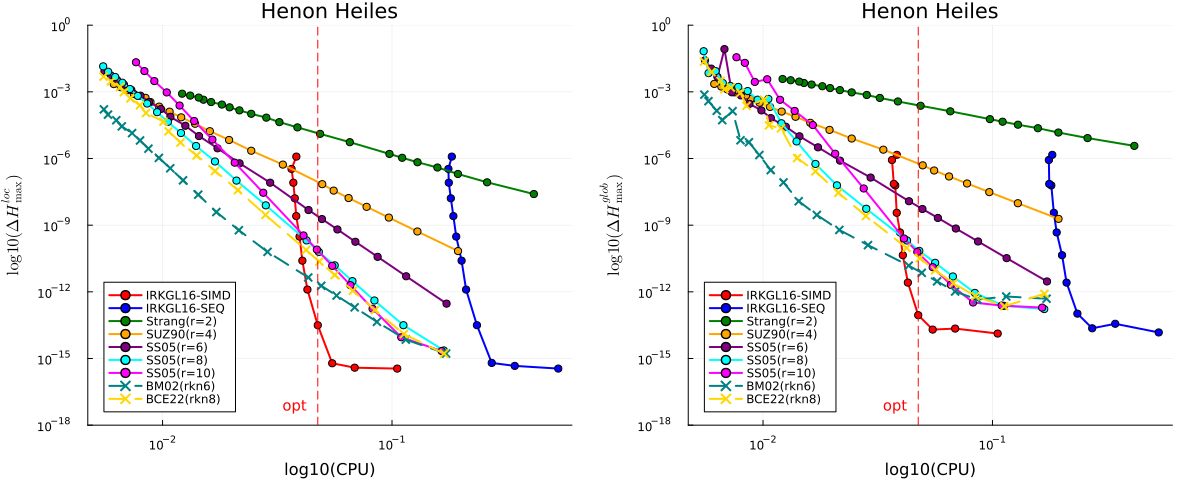

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [17]:
yrange=(1e-18, 1e0)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=:circle, lw=2,
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          legend=:bottomleft,
          title="Henon Heiles", xlabel="log10(CPU)", ylabel=L"\log10(\Delta H^{loc}_{\mathrm{max}})")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    if occursin("rkn", labels2plot[i])
        
        plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
        markershape=:xcross, lw=2, ls=:dash,
        label=labels2plot[i], color=colors2plot[i],
        scale=:log10)
    
    else
        plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
        markershape=:circle, lw=2,
        label=labels2plot[i], color=colors2plot[i],
        scale=:log10)
    end
    
end

vline!(pl1, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.38, 0.05), text("opt", :red, 10, :center))

#########################################

sols=sols_irk16_simd
pl2=plot( sols.cpus , sols.MaxΔHglobal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange, 
         label=labels2plot[1], color=colors2plot[1],
         legend=:bottomleft,
         title="Henon Heiles", xlabel="log10(CPU)", ylabel=L"\log10(\Delta H^{glob}_{\mathrm{max}})")


for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
   if occursin("rkn", labels2plot[i])
        
        plot!(pl2, sols.cpus , sols.MaxΔHglobal, 
        markershape=:xcross, lw=2, ls=:dash,
        label=labels2plot[i], color=colors2plot[i],
        scale=:log10)
    
    else
        plot!(pl2, sols.cpus , sols.MaxΔHglobal, 
        markershape=:circle, lw=2,
        label=labels2plot[i], color=colors2plot[i],
        scale=:log10)
    end

end

vline!(pl2, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.38, 0.05), text("opt", :red, 10, :center))

plot(pl1, pl2, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

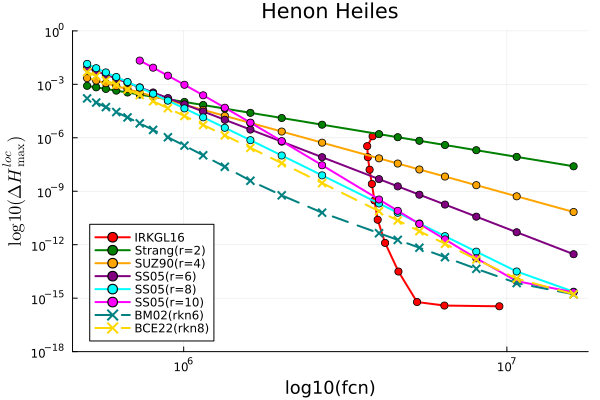

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [18]:
fcn=8*(sols_irk16_simd.iters)


sols=sols_irk16_simd
pl3=plot( fcn , sols.MaxΔHlocal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange,    
         label="IRKGL16", color=colors2plot[1],
         title="Henon Heiles", 
         xlabel="log10(fcn)", ylabel=L"\log10(\Delta H^{loc}_{\mathrm{max}})",
         legend=:bottomleft,
         guidefont=font(12), labelsize=10)


for i in 3:length(sols2plot)
       
   sols=sols2plot[i]
    
   if occursin("rkn", labels2plot[i])
       plot!(pl3, sols.nflowsH3 , sols.MaxΔHlocal, 
       markershape=:xcross, lw=2, ls=:dash,
       label=labels2plot[i], color=colors2plot[i],
       scale=:log10)
        
   else 
       plot!(pl3, sols.nflowsH3 , sols.MaxΔHlocal, 
             markershape=:circle, lw=2,
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)
   end

end

display(pl3)

In [19]:
savefig("./figures/Fig3a.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article/Henon-Heiles-Non-Chaotic/figures/Fig3a.pdf"

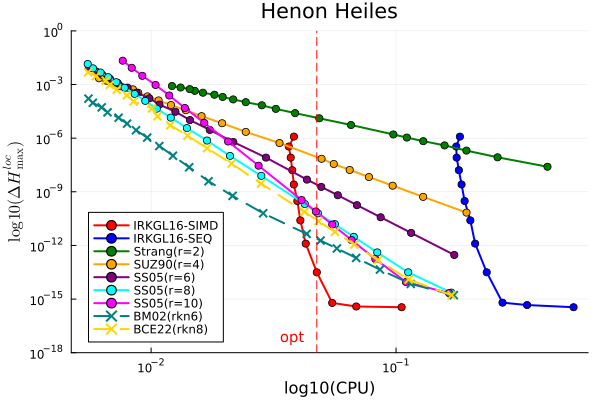

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [20]:
plot(pl1) #plot(pl2)

In [21]:
savefig("./figures/Fig3b.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article/Henon-Heiles-Non-Chaotic/figures/Fig3b.pdf"

<a href="#top">Back to the top</a>

### Error in Energy

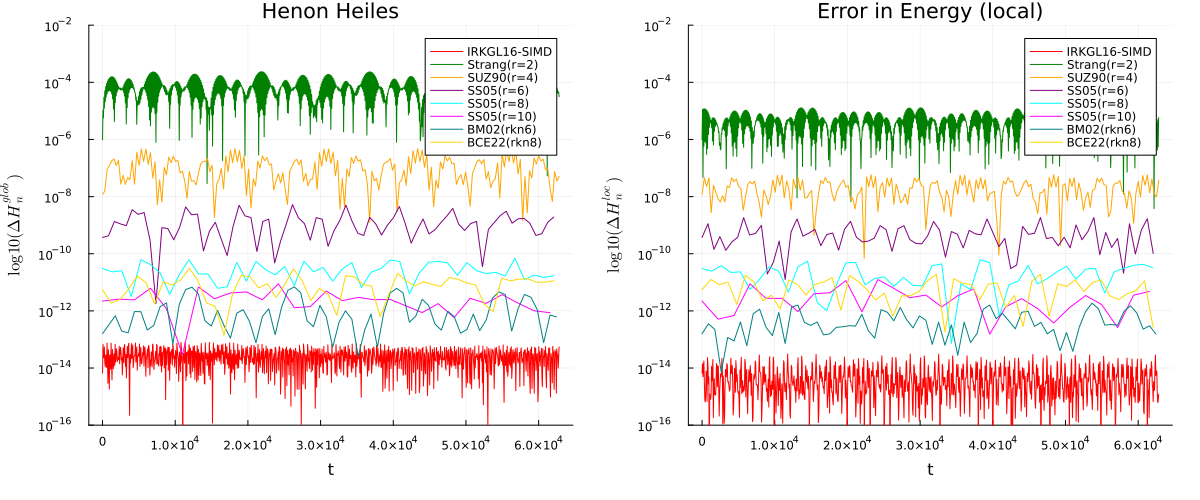

In [22]:
yrange=(1e-16, 1e-2)

onesols2plot=[sols_irk16_simd.sols[index[1]], sols_split_r2.sols[index[3]], sols_split_r4.sols[index[4]],
              sols_split_r6.sols[index[5]],   sols_split_r8.sols[index[6]], sols_split_r10.sols[index[7]],
              sols_split_rkn6.sols[index[8]], sols_split_rkn8.sols[index[9]]]


HAM=HenonHeliesHam
H0=HAM(u0_B,parms)


H = [HAM(BigFloat.(u),parms) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))
ΔH0loc = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

pl3=plot(sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
        ylimits=yrange,
        xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",title="Henon Heiles",
        label=labels2plot[1],color=colors2plot[1],
        yscale=:log10, legend=:topright)

pl4=plot(sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0loc[1:m0:end]),
        ylimits=yrange,
        xlabel="t", ylabel=L"\log10(\Delta H^{loc}_n)",title="Error in Energy (local)",
        label=labels2plot[1],color=colors2plot[1],
        yscale=:log10)

# splitting

for k in 2:length(onesols2plot)
    m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_split[index[k+1]])),1000))
    solk=onesols2plot[k]
    labelk=labels2plot[k+1]
    colork=colors2plot[k+1]
    H = [HAM(BigFloat.(u),parms) for u in solk.u]
    ΔH0 = @. Float64(abs(H/H0-1))
    ΔH0loc = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
    plot!(pl3, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, label=labelk, color=colork)
    plot!(pl4, solk.t[2:m0:end], abs.(ΔH0loc[1:m0:end]), yscale=:log10, label=labelk, color=colork)
end


fig=plot(pl3, pl4, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

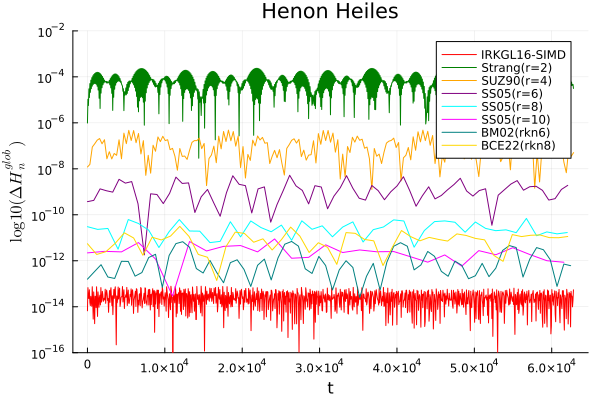

In [23]:
plot(pl3)

In [24]:
savefig("./figures/Fig3c.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article/Henon-Heiles-Non-Chaotic/figures/Fig3c.pdf"

<a href="#top">Back to the top</a>

### Error in Solution

In [25]:
#=
errors2plot=[sols_irk16_simd.sols[index[1]], sols_split_r2.sols[index[3]], sols_split_r4.sols[index[4]],
              sols_split_r6.sols[index[5]],   sols_split_r8.sols[index[6]], sols_split_r10.sols[index[7]],
              sols_split_rkn6.sols[index[8]], sols_split_rkn8.sols[index[9]]]
=#

errors2plot=[sols_irk16_simd.sols[index[1]], sols_split_r10.sols[index[7]], sols_split_rkn6.sols[index[8]], sols_split_rkn8.sols[index[9]]]
#=
ddt02plot=[sols_irk16_simd.dts[index[1]], sols_split_r2.dts[index[3]], sols_split_r4.dts[index[4]],
           sols_split_r6.dts[index[5]],   sols_split_r8.dts[index[6]], sols_split_r10.dts[index[7]],
           sols_split_rkn6.dts[index[8]], sols_split_rkn8.dts[index[9]]]
=#

ddt02plot=[sols_irk16_simd.dts[index[1]],  sols_split_r10.dts[index[7]], sols_split_rkn6.dts[index[8]], sols_split_rkn8.dts[index[9]]]

#=
labels2plot_er=["IRKGL16(simd)",  
                "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)",
                "BM02(rkn6)", "BCE22(rkn8)"] 
=#

labels2plot_er=["IRKGL16(simd)",  "SS05(r=10)", "BM02(rkn6)", "BCE22(rkn8)"] 

#colors2plot_er=[:red, :green, :orange, :purple, :cyan, :magenta, :teal, :gold];

colors2plot_er=[:red,  :magenta, :teal, :gold];

In [26]:
yrange=(1e-16, 1e-4)


ploterr_q=plot(title="Henon Heiles",
                ylims=yrange,
                yscale=:log10,
                legend=:bottomright,
                xlabel="t",
                ylabel="error in position")

ploterr_p=plot(title="Henon Heiles",
                ylims=yrange,
                yscale=:log10,
                legend=:bottomright,
                xlabel="t",
                ylabel="error in momentum")


for k in 1:length(errors2plot)

        
    w=lcm_floats_vector(vcat(ddt0_irk16[index0],ddt02plot[k]))
    ii=Int64.(w./(vcat(ddt0_irk16[index0],ddt02plot[k]))).+1
    #ii=Int64.(round.(w./(vcat(ddt0_irk16[index0],ddt02plot[k]))))

    println("k=",k, ". w=", w, ",ii=",ii)


    v0=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:3*ii[1]] 
    v1=errors2plot[k].t[ii[2]:ii[2]-1:3*ii[2]]
    
    println("k=", k, ",",labels2plot[k],",", v0 )
    println("k=", k, ",",labels2plot[k],",", v1 )
    println("*****************************")
    
   
    errorq=map((u,u1)->norm(BigFloat.(u[1:2])-BigFloat.(u1[1:2]))/norm(BigFloat.(u1[1:2])), 
                      errors2plot[k].u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])

    errorp=map((u,u1)->norm(BigFloat.(u[3:4])-BigFloat.(u1[3:4]))/norm(BigFloat.(u1[3:4])), 
                      errors2plot[k].u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
      
    
    #tt=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:end]
    tt=errors2plot[k].t[ii[2]:ii[2]-1:end]
    
    plot!(ploterr_q, tt, errorq,
          label=labels2plot_er[k],color=colors2plot_er[k])
    
    plot!(ploterr_p, tt, errorp,
          label=labels2plot_er[k],color=colors2plot_er[k])


    
end

k=1. w=3//1,ii=[5, 4]
k=1,IRKGL16-SIMD,[3.0, 6.0, 9.0]
k=1,IRKGL16-SIMD,[3.0, 6.0, 9.0]
*****************************
k=2. w=105//4,ii=[36, 65]
k=2,IRKGL16-SEQ,[26.25, 52.5, 78.75]
k=2,IRKGL16-SEQ,[26.25, 52.5, 78.75]
*****************************
k=3. w=147//4,ii=[50, 193]
k=3,Strang(r=2),[36.75, 73.5, 110.25]
k=3,Strang(r=2),[36.75, 73.5, 110.25]
*****************************
k=4. w=399//4,ii=[134, 385]
k=4,SUZ90(r=4),[99.75, 199.5, 299.25]
k=4,SUZ90(r=4),[99.75, 199.5, 299.25]
*****************************


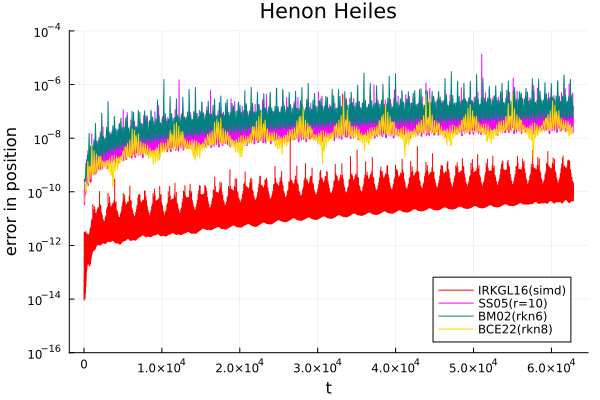

In [27]:
plot(ploterr_q)

In [28]:
savefig("./figures/Fig3d-1.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article/Henon-Heiles-Non-Chaotic/figures/Fig3d-1.pdf"

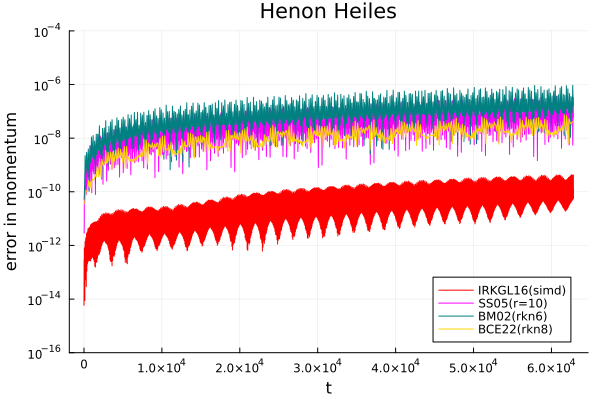

In [29]:
plot(ploterr_p)


In [30]:
savefig("./figures/Fig3d-2.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article/Henon-Heiles-Non-Chaotic/figures/Fig3d-2.pdf"